In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import optuna
from sklearn.feature_selection import VarianceThreshold,RFE, mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix,accuracy_score, precision_score, recall_score, f1_score, make_scorer, precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [14]:
fold_1_train = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_1_train.csv')
fold_2_train = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_2_train.csv')
fold_3_train = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_3_train.csv')
fold_4_train = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_4_train.csv')
fold_5_train = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_5_train.csv')

fold_1_val = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_1_val.csv')
fold_2_val = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_2_val.csv')
fold_3_val = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_3_val.csv')
fold_4_val = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_4_val.csv')
fold_5_val = pd.read_csv('/Users/P1366370/Downloads/data/preprocessed/fold_5_val.csv')

In [15]:
train_folds = [fold_1_train, fold_2_train, fold_3_train, fold_4_train, fold_5_train]
val_folds = [fold_1_val, fold_2_val, fold_3_val, fold_4_val, fold_5_val]

In [16]:
# Concatenate SMOTEd folds 1-4 for training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

# Use fold 5 as validation
X_val = fold_5_val.drop(columns='fraud_bool') 
y_val = fold_5_val['fraud_bool']

In [17]:
# Scale using training fold only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [18]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [19]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)

xgb_model.fit(X_train_scaled, y_train)

c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:33:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [20]:
# Get fraud probabilities
rf_probs = rf_model.predict_proba(X_val_scaled)[:, 1]
xgb_probs = xgb_model.predict_proba(X_val_scaled)[:, 1]

In [21]:
# Blending (adjust weights as needed)
blended_probs = 0.5 * rf_probs + 0.5 * xgb_probs

# Convert to binary prediction with threshold
threshold = 0.5  # Tune this if needed
blended_preds = (blended_probs >= threshold).astype(int)

In [5]:
def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Key Metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm.tolist()
    }

    # Probabilistic metrics
    if y_proba is not None:
        # AUC-PR (best for imbalanced problems)
        pr_auc = average_precision_score(y_true, y_proba)
        metrics['auc_pr'] = pr_auc
        print(f"AUC-PR (Average Precision): {pr_auc:.4f}")

        # PR Curve
        if plot_pr_curve:
            precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)
            plt.figure(figsize=(6, 5))
            plt.plot(recall_pts, precision_pts, marker='.', label='PR Curve')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return metrics

Classification Report:
              precision    recall  f1-score   support

           0     0.9983    1.0000    0.9992    178711
           1     1.0000    0.8458    0.9165      1920

    accuracy                         0.9984    180631
   macro avg     0.9992    0.9229    0.9578    180631
weighted avg     0.9984    0.9984    0.9983    180631


Confusion Matrix:
[[178711      0]
 [   296   1624]]

Precision: 1.0000
Recall:    0.8458
F1 Score:  0.9165
AUC-PR (Average Precision): 1.0000


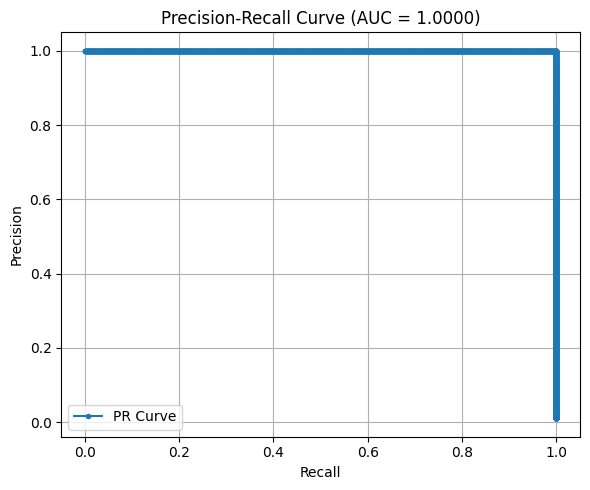

In [22]:
# Evaluate ensemble model
metrics = evaluate_model(y_val, blended_preds, y_proba=blended_probs, plot_pr_curve=True)

### Optuna Hyperparameter Tuning

In [4]:
# Objective function for Optuna
def create_objective(X_train, y_train, X_val, y_val):
    def objective(trial):
        rf = RandomForestClassifier(
            n_estimators=trial.suggest_int('rf_n_estimators', 50, 300),
            max_depth=trial.suggest_int('rf_max_depth', 3, 20),
            min_samples_split=trial.suggest_int('rf_min_samples_split', 2, 20),
            random_state=42,
            n_jobs=-1
        )

        xgb = XGBClassifier(
            n_estimators=trial.suggest_int('xgb_n_estimators', 50, 300),
            max_depth=trial.suggest_int('xgb_max_depth', 3, 15),
            learning_rate=trial.suggest_float('xgb_learning_rate', 0.01, 0.3),
            subsample=trial.suggest_float('xgb_subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('xgb_colsample_bytree', 0.5, 1.0),
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
            n_jobs=-1
        )

        blend_weight = trial.suggest_float('blend_weight', 0.1, 0.9)

        rf.fit(X_train, y_train)
        xgb.fit(X_train, y_train)

        rf_probs = rf.predict_proba(X_val)[:, 1]
        xgb_probs = xgb.predict_proba(X_val)[:, 1]
        blended_probs = (1 - blend_weight) * rf_probs + blend_weight * xgb_probs

        return average_precision_score(y_val, blended_probs)
    return objective

In [6]:
# Load your folds
def load_fold_data():
    train_folds = []
    val_folds = []
    for i in range(1, 6):
        train_folds.append(pd.read_csv(f'/Users/P1366370/Downloads/data/preprocessed/fold_{i}_train.csv'))
        val_folds.append(pd.read_csv(f'/Users/P1366370/Downloads/data/preprocessed/fold_{i}_val.csv'))
    return train_folds, val_folds

train_folds, val_folds = load_fold_data()

In [7]:
tuned_params_per_fold = []

# Tune with folds 1–4
for i in range(4):
    print(f"\nTuning Fold {i+1} (Validation)")

    train_data = pd.concat([df for j, df in enumerate(train_folds[:4]) if j != i])
    val_data = val_folds[i]

    X_train = train_data.drop(columns='fraud_bool')
    y_train = train_data['fraud_bool']
    X_val = val_data.drop(columns='fraud_bool')
    y_val = val_data['fraud_bool']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Sample 1 million rows while preserving the 50/50 balance
    X_train_sample, _, y_train_sample, _ = train_test_split(
        X_train_scaled,
        y_train,
        train_size=1_000_000,
        stratify=y_train,
        random_state=42
    )

    study = optuna.create_study(direction='maximize')
    study.optimize(create_objective(X_train_sample, y_train_sample, X_val_scaled, y_val), n_trials=10, show_progress_bar=True)
    
    tuned_params_per_fold.append(study.best_params)



Tuning Fold 1 (Validation)


[I 2025-04-16 19:47:43,660] A new study created in memory with name: no-name-fd6d60c5-193f-4316-af06-3a7885ed2022


  0%|          | 0/10 [00:00<?, ?it/s]

c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [19:52:05] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[I 2025-04-16 19:52:36,076] Trial 0 finished with value: 0.299027885933729 and parameters: {'rf_n_estimators': 213, 'rf_max_depth': 12, 'rf_min_samples_split': 15, 'xgb_n_estimators': 219, 'xgb_max_depth': 8, 'xgb_learning_rate': 0.18926330288771376, 'xgb_subsample': 0.5234625084184613, 'xgb_colsample_bytree': 0.6240263997010411, 'blend_weight': 0.6560401641930853}. Best is trial 0 with value: 0.299027885933729.


...

[I 2025-04-16 21:44:27,102] Trial 7 finished with value: 0.13085716452493107 and parameters: {'rf_n_estimators': 150, 'rf_max_depth': 7, 'rf_min_samples_split': 8, 'xgb_n_estimators': 179, 'xgb_max_depth': 5, 'xgb_learning_rate': 0.24201863130664542, 'xgb_subsample': 0.7219394553043424, 'xgb_colsample_bytree': 0.6101207356871203, 'blend_weight': 0.5051337977173171}. Best is trial 5 with value: 0.6084728691293714.


c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:47:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[I 2025-04-16 21:48:12,073] Trial 8 finished with value: 0.10752454327910198 and parameters: {'rf_n_estimators': 202, 'rf_max_depth': 11, 'rf_min_samples_split': 11, 'xgb_n_estimators': 191, 'xgb_max_depth': 7, 'xgb_learning_rate': 0.04981287115301837, 'xgb_subsample': 0.7251339390350222, 'xgb_colsample_bytree': 0.5400000775088383, 'blend_weight': 0.469578712352715}. Best is trial 5 with value: 0.6084728691293714.


c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:49:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[I 2025-04-16 21:50:12,764] Trial 9 finished with value: 0.2101103296652535 and parameters: {'rf_n_estimators': 59, 'rf_max_depth': 20, 'rf_min_samples_split': 20, 'xgb_n_estimators': 185, 'xgb_max_depth': 10, 'xgb_learning_rate': 0.1195436165477464, 'xgb_subsample': 0.7240057677559246, 'xgb_colsample_bytree': 0.8326285405603706, 'blend_weight': 0.13868633649598305}. Best is trial 5 with value: 0.6084728691293714.



Evaluating Fold 1 with Tuned Parameters


c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:15:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Classification Report:
              precision    recall  f1-score   support

           0     0.9995    0.9996    0.9995    178712
           1     0.9597    0.9563    0.9580      1920

    accuracy                         0.9991    180632
   macro avg     0.9796    0.9779    0.9788    180632
weighted avg     0.9991    0.9991    0.9991    180632


Confusion Matrix:
[[178635     77]
 [    84   1836]]

Precision: 0.9597
Recall:    0.9563
F1 Score:  0.9580
AUC-PR (Average Precision): 0.9852


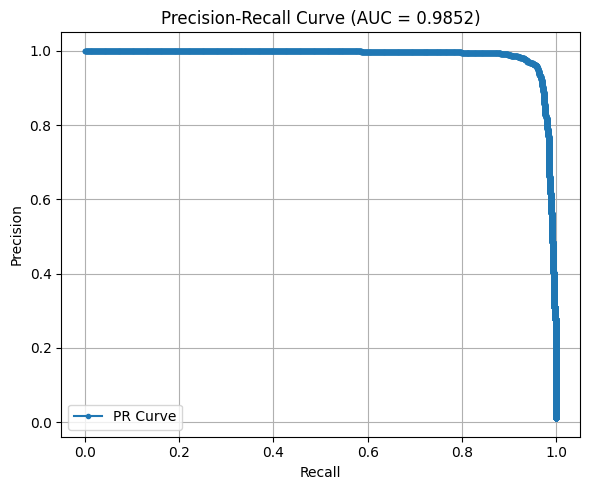

Fold 1 Metrics: {'precision': 0.9597490852064819, 'recall': 0.95625, 'f1_score': 0.957996347508479, 'confusion_matrix': [[178635, 77], [84, 1836]], 'auc_pr': np.float64(0.9852485887825655), 'threshold': np.float64(0.41585858585858587)}

Evaluating Fold 2 with Tuned Parameters


c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:42:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    178711
           1     0.9964    0.9974    0.9969      1921

    accuracy                         0.9999    180632
   macro avg     0.9982    0.9987    0.9984    180632
weighted avg     0.9999    0.9999    0.9999    180632


Confusion Matrix:
[[178704      7]
 [     5   1916]]

Precision: 0.9964
Recall:    0.9974
F1 Score:  0.9969
AUC-PR (Average Precision): 0.9999


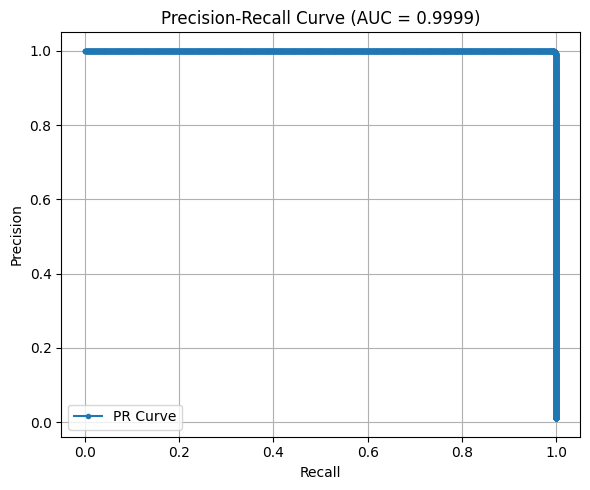

Fold 2 Metrics: {'precision': 0.9963598543941757, 'recall': 0.9973971889640812, 'f1_score': 0.9968782518210197, 'confusion_matrix': [[178704, 7], [5, 1916]], 'auc_pr': np.float64(0.9999370336664195), 'threshold': np.float64(0.4851515151515151)}

Evaluating Fold 3 with Tuned Parameters


c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:47:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    178711
           1     1.0000    1.0000    1.0000      1920

    accuracy                         1.0000    180631
   macro avg     1.0000    1.0000    1.0000    180631
weighted avg     1.0000    1.0000    1.0000    180631


Confusion Matrix:
[[178711      0]
 [     0   1920]]

Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
AUC-PR (Average Precision): 1.0000


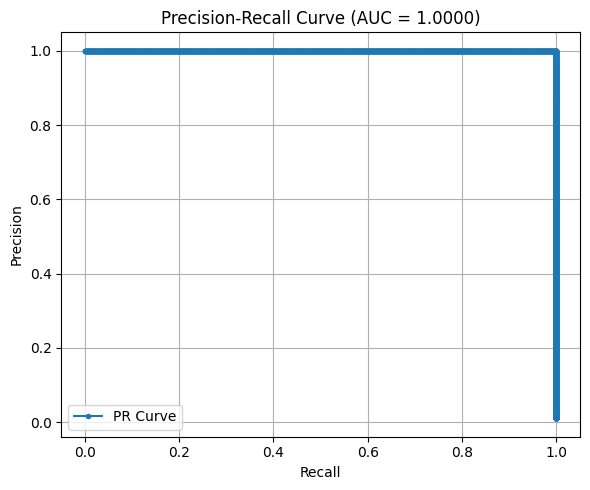

Fold 3 Metrics: {'precision': 1.0, 'recall': 1.0, 'f1_score': 1.0, 'confusion_matrix': [[178711, 0], [0, 1920]], 'auc_pr': np.float64(1.0), 'threshold': np.float64(0.33666666666666667)}

Evaluating Fold 4 with Tuned Parameters


c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:55:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Classification Report:
              precision    recall  f1-score   support

           0     0.9992    0.9996    0.9994    178711
           1     0.9584    0.9245    0.9411      1920

    accuracy                         0.9988    180631
   macro avg     0.9788    0.9620    0.9703    180631
weighted avg     0.9988    0.9988    0.9988    180631


Confusion Matrix:
[[178634     77]
 [   145   1775]]

Precision: 0.9584
Recall:    0.9245
F1 Score:  0.9411
AUC-PR (Average Precision): 0.9861


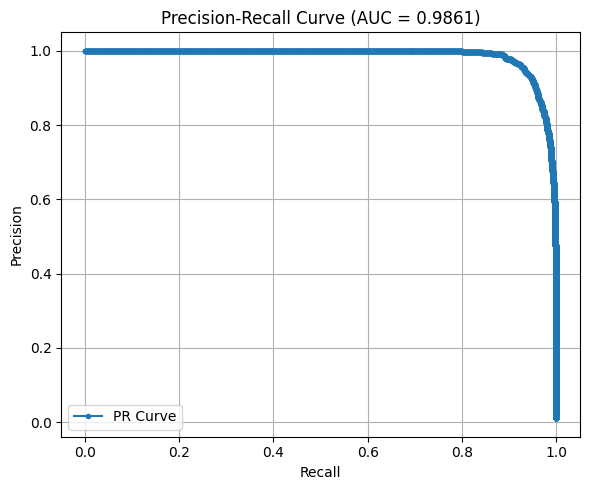

Fold 4 Metrics: {'precision': 0.9584233261339092, 'recall': 0.9244791666666666, 'f1_score': 0.9411452810180275, 'confusion_matrix': [[178634, 77], [145, 1775]], 'auc_pr': np.float64(0.9860693758596708), 'threshold': np.float64(0.5148484848484849)}


In [8]:
all_metrics = []

for i in range(4):
    print(f"\nEvaluating Fold {i+1} with Tuned Parameters")

    train_data = pd.concat([df for j, df in enumerate(train_folds[:4]) if j != i])
    val_data = val_folds[i]

    X_train = train_data.drop(columns='fraud_bool')
    y_train = train_data['fraud_bool']
    X_val = val_data.drop(columns='fraud_bool')
    y_val = val_data['fraud_bool']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    best_params = tuned_params_per_fold[i]
    blend_weight = best_params['blend_weight']

    best_rf = RandomForestClassifier(
        n_estimators=best_params['rf_n_estimators'],
        max_depth=best_params['rf_max_depth'],
        min_samples_split=best_params['rf_min_samples_split'],
        random_state=42,
        n_jobs=-1
    )
    best_xgb = XGBClassifier(
        n_estimators=best_params['xgb_n_estimators'],
        max_depth=best_params['xgb_max_depth'],
        learning_rate=best_params['xgb_learning_rate'],
        subsample=best_params['xgb_subsample'],
        colsample_bytree=best_params['xgb_colsample_bytree'],
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )

    best_rf.fit(X_train_scaled, y_train)
    best_xgb.fit(X_train_scaled, y_train)

    rf_probs = best_rf.predict_proba(X_val_scaled)[:, 1]
    xgb_probs = best_xgb.predict_proba(X_val_scaled)[:, 1]
    blended_probs = (1 - blend_weight) * rf_probs + blend_weight * xgb_probs

    thresholds = np.linspace(0.01, 0.99, 100)
    best_thresh = thresholds[np.argmax([average_precision_score(y_val, (blended_probs >= t).astype(int)) for t in thresholds])]
    final_preds = (blended_probs >= best_thresh).astype(int)

    metrics = evaluate_model(y_val, final_preds, blended_probs)
    metrics['threshold'] = best_thresh
    all_metrics.append(metrics)

    print(f"Fold {i+1} Metrics:", metrics)

In [9]:
# Average hyperparameters across folds
from statistics import mean

def average_params(tuned_params_list):
    numeric_keys = ['rf_n_estimators', 'rf_max_depth', 'rf_min_samples_split',
                    'xgb_n_estimators', 'xgb_max_depth', 'xgb_learning_rate',
                    'xgb_subsample', 'xgb_colsample_bytree', 'blend_weight']
    
    avg_params = {
        key: mean([params[key] for params in tuned_params_list]) for key in numeric_keys
    }
    # Round where appropriate
    int_keys = ['rf_n_estimators', 'rf_max_depth', 'rf_min_samples_split',
                'xgb_n_estimators', 'xgb_max_depth']
    for key in int_keys:
        avg_params[key] = int(round(avg_params[key]))
    
    return avg_params

final_params = average_params(tuned_params_per_fold)
blend_weight = final_params['blend_weight']

In [10]:
# Train final models
final_rf = RandomForestClassifier(
    n_estimators=final_params['rf_n_estimators'],
    max_depth=final_params['rf_max_depth'],
    min_samples_split=final_params['rf_min_samples_split'],
    random_state=42,
    n_jobs=-1
)

final_xgb = XGBClassifier(
    n_estimators=final_params['xgb_n_estimators'],
    max_depth=final_params['xgb_max_depth'],
    learning_rate=final_params['xgb_learning_rate'],
    subsample=final_params['xgb_subsample'],
    colsample_bytree=final_params['xgb_colsample_bytree'],
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)


In [11]:
final_rf.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=9, min_samples_split=12, n_estimators=211,
                       n_jobs=-1, random_state=42)

In [12]:
final_xgb.fit(X_train_scaled, y_train)

c:\Users\P1366370\AppData\Local\Programs\Python\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:12:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7779118327714571, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.22255531519560576,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=12, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=225, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    178711
           1     0.9969    0.9969    0.9969      1920

    accuracy                         0.9999    180631
   macro avg     0.9984    0.9984    0.9984    180631
weighted avg     0.9999    0.9999    0.9999    180631


Confusion Matrix:
[[178705      6]
 [     6   1914]]

Precision: 0.9969
Recall:    0.9969
F1 Score:  0.9969
AUC-PR (Average Precision): 0.9997


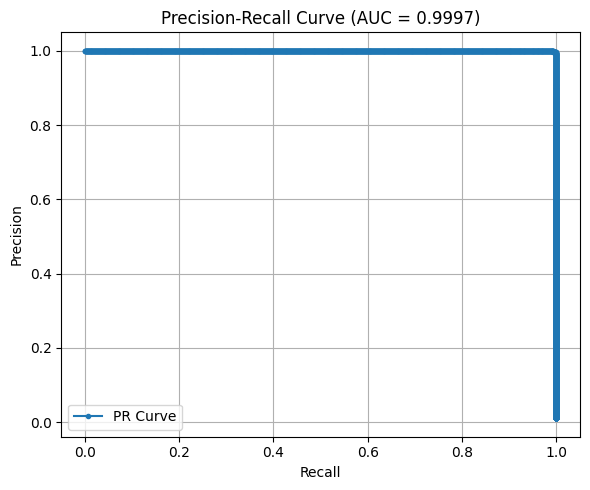

Final Evaluation on Fold 5:
{'precision': 0.996875, 'recall': 0.996875, 'f1_score': 0.996875, 'confusion_matrix': [[178705, 6], [6, 1914]], 'auc_pr': np.float64(0.999709226125749), 'threshold': np.float64(0.5049494949494949)}


In [13]:
# Predict and optimize threshold
rf_probs = final_rf.predict_proba(X_val_scaled)[:, 1]
xgb_probs = final_xgb.predict_proba(X_val_scaled)[:, 1]
blended_probs = (1 - blend_weight) * rf_probs + blend_weight * xgb_probs

thresholds = np.linspace(0.01, 0.99, 100)
best_thresh = thresholds[np.argmax([
    average_precision_score(y_val, (blended_probs >= t).astype(int)) for t in thresholds
])]

final_preds = (blended_probs >= best_thresh).astype(int)

# Final metrics
final_metrics = evaluate_model(y_val, final_preds, blended_probs)
final_metrics['threshold'] = best_thresh

print("Final Evaluation on Fold 5:")
print(final_metrics)
